In [2]:
import numpy as np
import pandas as pd
import os
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, LeakyReLU, BatchNormalization
from tensorflow.keras.layers import Dropout, Dot, multiply, Concatenate, subtract, UpSampling2D
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array
from tqdm import tqdm

In [2]:
dataset_dir = 'color'

l_image = []
ab_image = []


for filename in tqdm(os.listdir(dataset_dir)):
    img_path = os.path.join(dataset_dir, filename)

    image = cv2.imread(img_path)

    if image is None:
        continue

    #convert BRG to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (128, 128))

    
    # convert RGB to LAB color
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # Split into L, A, B
    L, A, B = cv2.split(lab)
    

    # creating AB channel
    AB = cv2.merge([A, B])

    # append
    l_image.append(L / 255.0)
    ab_image.append(AB / 128.0)



100%|██████████████████████████████████████| 7130/7130 [00:07<00:00, 948.71it/s]


In [3]:
l_image = np.array(l_image)
ab_image = np.array(ab_image)

In [5]:
l_image = l_image.reshape(-1, 128, 128, 1)

In [7]:
print(l_image.shape, ab_image.shape)

(7129, 128, 128, 1) (7129, 128, 128, 2)


In [8]:
x_train, x_test, y_train, y_test = train_test_split(l_image, ab_image, test_size = 0.2)

In [9]:
print(x_train.shape, x_test.shape)

(5703, 128, 128, 1) (1426, 128, 128, 1)


In [10]:
print(y_train.shape, y_test.shape)

(5703, 128, 128, 2) (1426, 128, 128, 2)


In [11]:
# building the actual model

model = Sequential()

# encoder
model.add(Conv2D(64, kernel_size = (3,3), padding = 'same', activation = 'relu', input_shape = (128, 128, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'same')) # 

model.add(Conv2D(128, kernel_size = (3,3), padding = 'same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding = 'same')) # 64

model.add(Conv2D(256, kernel_size = (3,3), padding = 'same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding = 'same')) # 64


# Bottleneck
model.add(Conv2D(512, kernel_size = (3,3), padding='same', activation = 'relu'))
model.add(BatchNormalization())

# Deconder
model.add(UpSampling2D((2,2))) # 128
model.add(Conv2D(256, kernel_size = (3,3), padding = 'same', activation = 'relu'))
model.add(BatchNormalization())

model.add(UpSampling2D((2,2))) # 256
model.add(Conv2D(128, kernel_size = (3,3), padding = 'same', activation = 'relu'))
model.add(BatchNormalization())

model.add(UpSampling2D((2,2))) # 256
model.add(Conv2D(64, kernel_size = (3,3), padding = 'same', activation = 'relu'))
model.add(BatchNormalization())

# final layer
model.add(Conv2D(2, kernel_size = (1,1), activation = 'tanh', padding = 'same'))

# compilation
optimizer = keras.optimizers.Adam(learning_rate = 0.01)
model.compile(loss = 'mse', optimizer = optimizer, metrics = ['mse'])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 2)    │           130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 3,104,322 (11.84 MB)

 Trainable params: 3,101,506 (11.83 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [13]:
history = model.fit(x_train, y_train, epochs = 10, validation_data = (x_test, y_test))

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 853s 5s/step - loss: 0.0840 - mse: 0.0840 - val_loss: 0.0203 - val_mse: 0.0203
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1386s 8s/step - loss: 0.0120 - mse: 0.0120 - val_loss: 0.0120 - val_mse: 0.0120
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1546s 9s/step - loss: 0.0114 - mse: 0.0114 - val_loss: 0.0114 - val_mse: 0.0114
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1589s 9s/step - loss: 0.0110 - mse: 0.0110 - val_loss: 0.0111 - val_mse: 0.0111
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1586s 9s/step - loss: 0.0108 - mse: 0.0108 - val_loss: 0.0105 - val_mse: 0.0105
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1579s 9s/step - loss: 0.0108 - mse: 0.0108 - val_loss: 0.0105 - val_mse: 0.0105
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1592s 9s/step - loss: 0.0106 - mse: 0.0106 - val_loss: 0.0103 - val_mse: 0.0103
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1327s 7s/step - loss: 0.0106 - mse: 0.0106 - val_loss: 0.0105 - val_mse: 0.0105
Epoch 9/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1

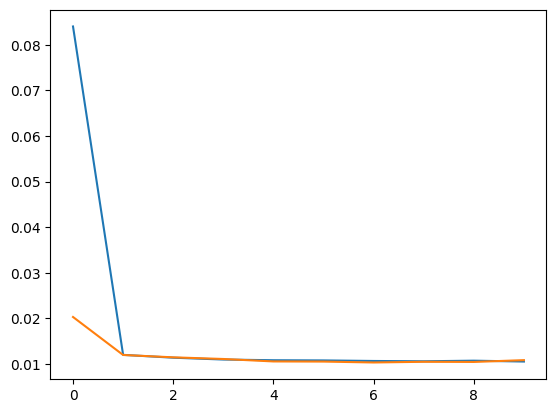

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


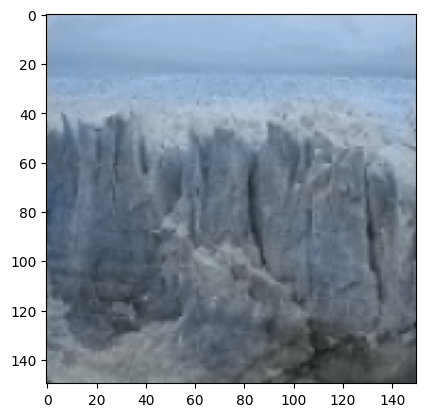

(0.0, 1.0, 0.0, 1.0)

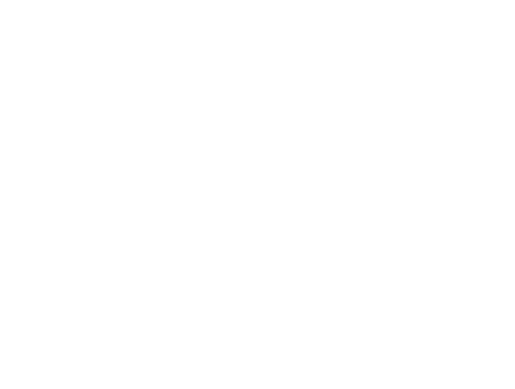

In [23]:
x = x_test[9].astype('float32')
x_input = np.expand_dims(x, axis=0)  # shape becomes (1, 128, 128, 1)

y = model.predict(x_input)
y = y[0]

x = x * 255
y = y * 128

x = x.astype('uint8')
y = y.astype('uint8')
#print(x.shape)
#print(y.shape)

y1, y2 = cv2.split(y)

#print(y1.shape)
#print(y2.shape)

image = cv2.merge([x, y1, y2])
ab = cv2.merge([y1, y2])
#print(ab.shape)

image = cv2.cvtColor(image, cv2.COLOR_LAB2RGB)
image = cv2.resize(image, (150, 150))
plt.imshow(image)
plt.show()
plt.axis('off')

In [18]:
print("x_test shape:", x_test.shape)
print("x_test dtype:", x_test.dtype)

sample = x_test[19]
print("single sample shape:", sample.shape)

sample = np.expand_dims(sample, axis=0)
print("after expand:", sample.shape)

y = model.predict(sample)
print("output shape:", y.shape)

x_test shape: (1426, 128, 128, 1)
x_test dtype: float64
single sample shape: (128, 128, 1)
after expand: (1, 128, 128, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
output shape: (1, 128, 128, 2)


In [19]:
# The mean square error

loss, mse = model.evaluate(x_test, y_test)
print(f"Test MSE: {mse}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 899ms/step - loss: 0.0108 - mse: 0.0108
Test MSE: 0.010823034681379795


In [20]:
from skimage.metrics import peak_signal_noise_ratio as psnr
y_pred = model.predict(x_test)

total_psnr = 0
for i in range(len(y_test)):
    y_test = y_test * 128
    y_test = y_test.astype('uint8')
    psnr(y_test[i], y_pred[i])
    total_psnr += psnr(y_test[i], y_pred[i])

avg_psnr = total_psnr / len(y_test)
print(f"Average PSNR: {avg_psnr:.2f} dB")

45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 897ms/step


/var/folders/49/dlfryms541x6nvjcz5yz0hh80000gn/T/ipykernel_28076/1597503420.py:8: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr(y_test[i], y_pred[i])
/var/folders/49/dlfryms541x6nvjcz5yz0hh80000gn/T/ipykernel_28076/1597503420.py:9: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  total_psnr += psnr(y_test[i], y_pred[i])


Average PSNR: 48.32 dB


### The peak signal to noise ratio (PSNR) is = 48.32 dB

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


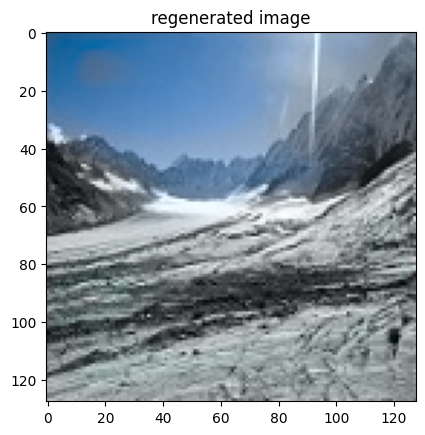

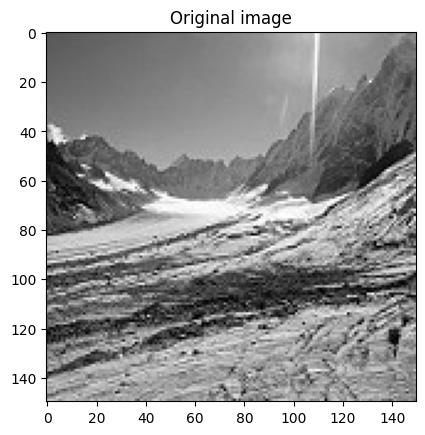

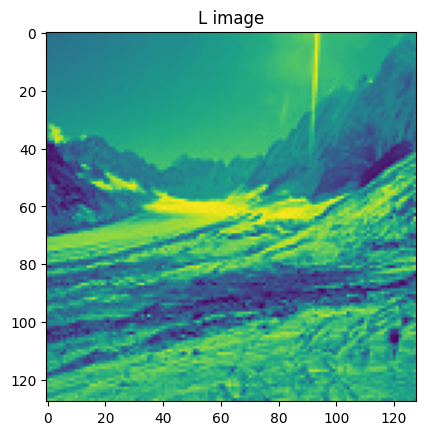

In [58]:
x_bw = cv2.imread("4_bw.jpg")
#resize
x = cv2.resize(x_bw, (128, 128))
# change BGR to RGB
x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
# RGB to LAB
lab = cv2.cvtColor(x, cv2.COLOR_RGB2LAB)
#split into three channels
L, A, B = cv2.split(lab)
x_in = L / 255
# resize x input 
x_in = x_in.reshape((128, 128, 1))
x = np.expand_dims(x_in, axis = 0)
# prediction
y = model.predict(x)
x_in = x_in * 255
y = y * 128
x_in = x_in.astype('uint8')
y = y.astype('uint8')
y = y[0]
y1, y2 = cv2.split(y)
# image in LAB format
image = cv2.merge([x_in, y1, y2])
# convert LAB image to RGB format
image = cv2.cvtColor(image, cv2.COLOR_LAB2RGB)
# show generated image
plt.title("regenerated image")
plt.imshow(image)
plt.show()
# converting the BGR image to RGB image (thew original image it is)
x_color = cv2.cvtColor(x_color, cv2.COLOR_BGR2RGB)
# show original image
plt.title("Original image")
plt.imshow(x_bw)
plt.show()
# show the L image
plt.title("L image")
plt.imshow(L)
plt.show()

In [3]:
# Using the recent format(keras) to save the model
model.save('colorization_model.keras')

In [1]:
# code to load the model later
# import load model from tensorflow keras
from tensorflow.keras.models import load_model
model = load_model("colorization_model.keras")
# predict any output later
#model.predict(...)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step


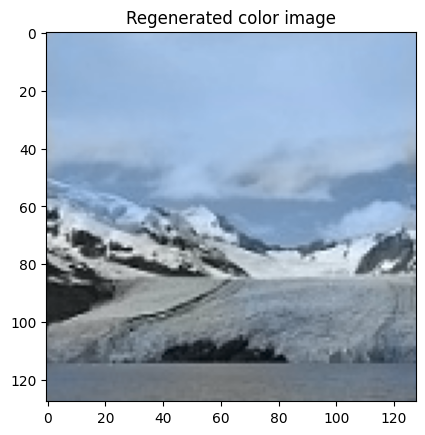

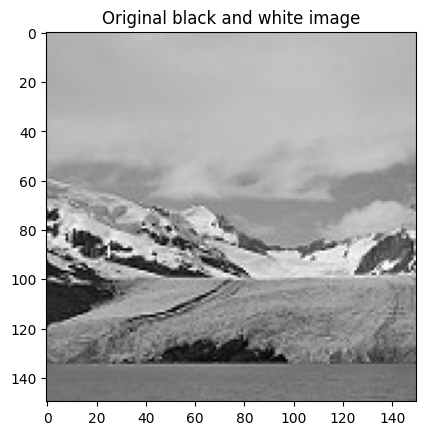

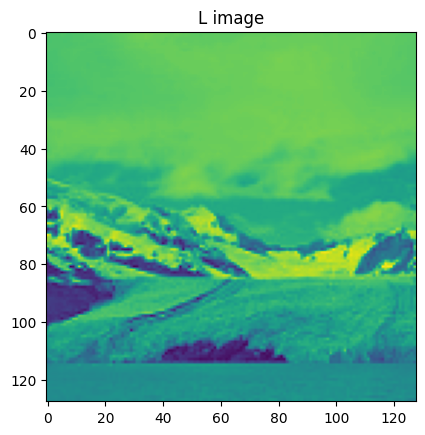

In [11]:
x_bw = cv2.imread("6930_bw.jpg")
#resize
x = cv2.resize(x_bw, (128, 128))
# change BGR to RGB
x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
# RGB to LAB
lab = cv2.cvtColor(x, cv2.COLOR_RGB2LAB)
#split into three channels
L, A, B = cv2.split(lab)
x_in = L / 255
# resize x input 
x_in = x_in.reshape((128, 128, 1))
x = np.expand_dims(x_in, axis = 0)
# prediction
y = model.predict(x)
x_in = x_in * 255
y = y * 128
x_in = x_in.astype('uint8')
y = y.astype('uint8')
y = y[0]
y1, y2 = cv2.split(y)
# image in LAB format
image = cv2.merge([x_in, y1, y2])
# convert LAB image to RGB format
image = cv2.cvtColor(image, cv2.COLOR_LAB2RGB)
# show generated image
plt.title("Regenerated color image")
plt.imshow(image)
plt.show()
# converting the BGR image to RGB image (the original image it is)
#x_color = cv2.cvtColor(x_color, cv2.COLOR_BGR2RGB)
# show original image
plt.title("Original black and white image")
plt.imshow(x_bw)
plt.show()
# show the L image
plt.title("L image")
plt.imshow(L)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


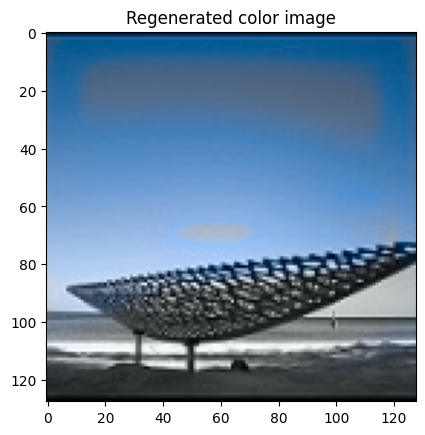

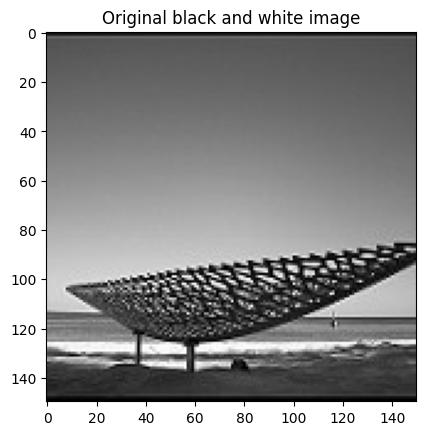

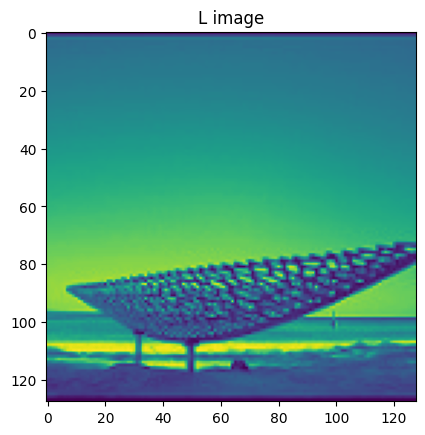

In [12]:
x_bw = cv2.imread("6580_bw.jpg")
#resize
x = cv2.resize(x_bw, (128, 128))
# change BGR to RGB
x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
# RGB to LAB
lab = cv2.cvtColor(x, cv2.COLOR_RGB2LAB)
#split into three channels
L, A, B = cv2.split(lab)
x_in = L / 255
# resize x input 
x_in = x_in.reshape((128, 128, 1))
x = np.expand_dims(x_in, axis = 0)
# prediction
y = model.predict(x)
x_in = x_in * 255
y = y * 128
x_in = x_in.astype('uint8')
y = y.astype('uint8')
y = y[0]
y1, y2 = cv2.split(y)
# image in LAB format
image = cv2.merge([x_in, y1, y2])
# convert LAB image to RGB format
image = cv2.cvtColor(image, cv2.COLOR_LAB2RGB)
# show generated image
plt.title("Regenerated color image")
plt.imshow(image)
plt.show()
# converting the BGR image to RGB image (the original image it is)
#x_color = cv2.cvtColor(x_color, cv2.COLOR_BGR2RGB)
# show original image
plt.title("Original black and white image")
plt.imshow(x_bw)
plt.show()
# show the L image
plt.title("L image")
plt.imshow(L)
plt.show()